In [2]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [46]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [47]:
t0 = 0
tE = 20
rho = 1.8e-6
rs = rho

u0_list =[0] #paper

secnum = 45
basenum = 2

q2=1.0        # equal-mass close pair
q3=1.2          # because qT=0.6 ⇒ m3/m1 = 1.2
s2=1.0          # binary separation in θE,B units
s3=15.3576      # distance lens1→third body (θE,B)

psi_deg=43.68   # third-body polar angle from lens1

num_points = 500

In [ ]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 45, psi_deg, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag


u0=0 VB y1[:5]=[-1.41421356 -1.40712477 -1.40003598 -1.39294719 -1.3858584 ] y2[:5]=[-1.41421356 -1.40712477 -1.40003598 -1.39294719 -1.3858584 ]
u0=0 analytic y1[:5]=[-1.41421356 -1.40712477 -1.40003598 -1.39294719 -1.3858584 ] y2[:5]=[-1.41421356 -1.40712477 -1.40003598 -1.39294719 -1.3858584 ]


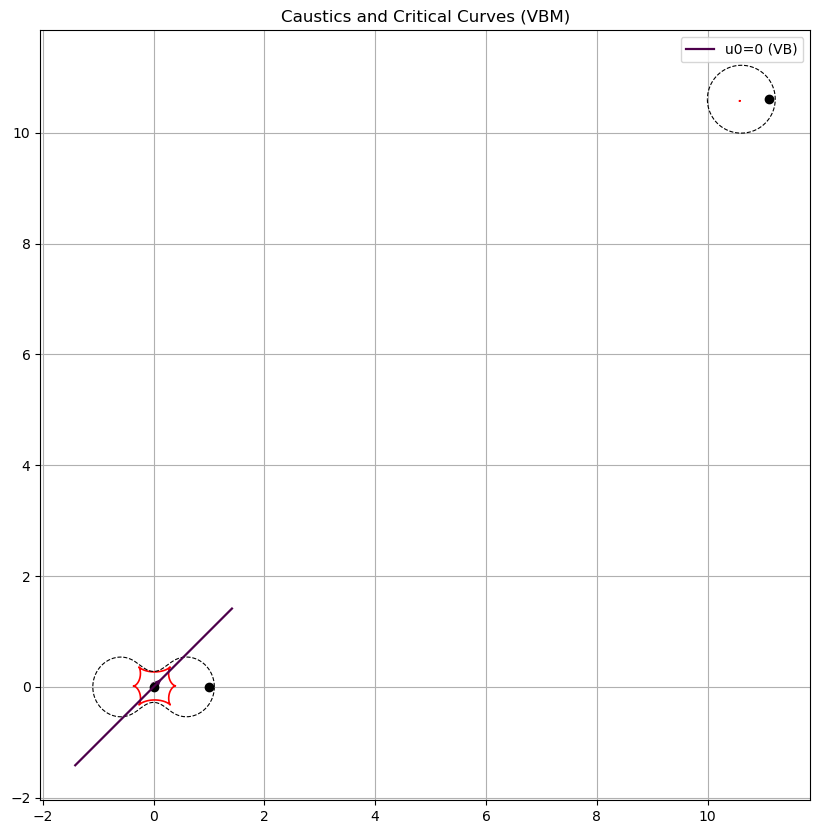

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Caustics and Critical Curves (VBM)'}>)

In [49]:
triple_model.plot_caustics_and_critical()

In [50]:
three_system  = triple_model.systems[0]

# 3L1S (standard res in your build)
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = delta_x_three
delta_y_three = -delta_y_three

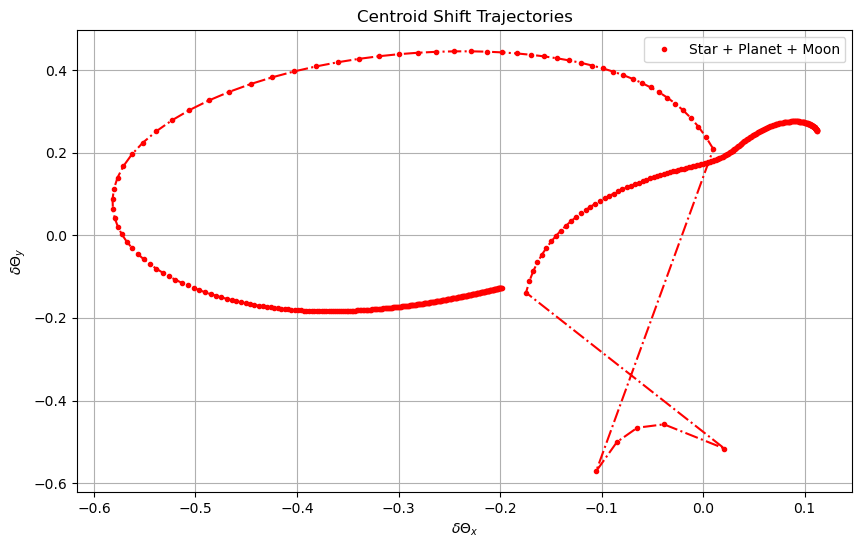

In [51]:
#centroid
plt.figure(figsize=(10, 6))

plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')

plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [3]:
from ML_amber import ThreeLensViz

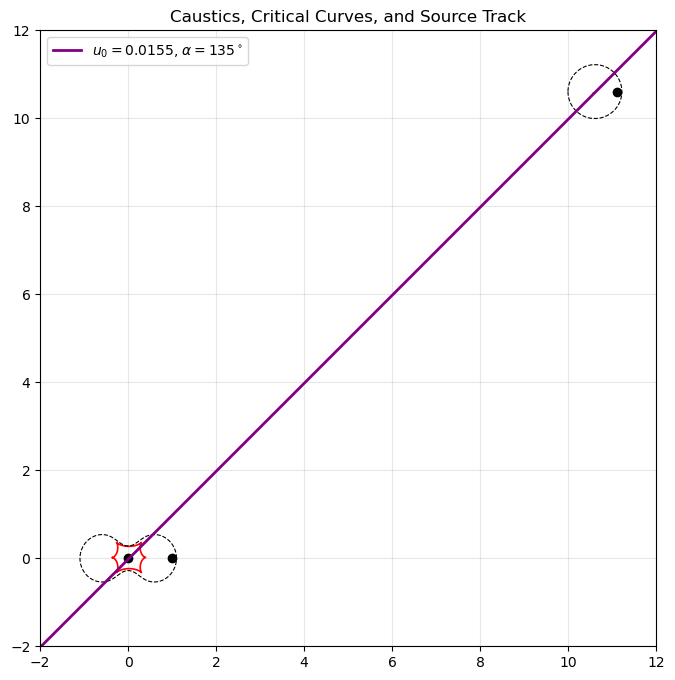

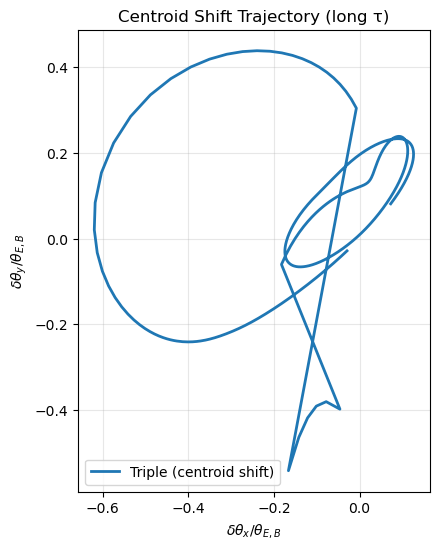

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Centroid Shift Trajectory (long τ)'}, xlabel='$\\delta \\theta_x / \\theta_{E,B}$', ylabel='$\\delta \\theta_y / \\theta_{E,B}$'>,
 (array([ 0.072525  ,  0.07266133,  0.07279821, ..., -0.02959171,
         -0.02957427, -0.02955683], shape=(3000,)),
  array([ 0.08123284,  0.0814138 ,  0.08159568, ..., -0.02875339,
         -0.02873695, -0.02872051], shape=(3000,))),
 (array([ 14.15309578,  14.14366454,  14.13423331, ..., -14.112313  ,
         -14.12174423, -14.13117547], shape=(3000,)),
  array([ 14.13117547,  14.12174423,  14.112313  , ..., -14.13423331,
         -14.14366454, -14.15309578], shape=(3000,))))

In [5]:
viz = ThreeLensViz(
    t0=0, tE=20, rho=1.8e-6,
    u0=0.0155,
    q2=1.0, q3=1.2,
    s2=1.0, s3=15.3576,
    alpha_deg=135,         # 35° or 55° gives a clean loop; 45° grazes the third body
    psi_deg=43.68,
    rs=1.8e-6, secnum=45, basenum=2,
    tau_min=-20, tau_max=+20, num_points=3000
)

# Caustics + full source track (use wide limits to include the third body region)
viz.plot_caustics_and_track(xlim=(-2, 12), ylim=(-2, 12))

# Centroid-shift loop
viz.plot_centroid_trajectory()
